[[ 4.40225453e-01 -1.76090181e-01  8.80450906e-01]
 [ 4.48595990e-01 -1.36040197e-01  8.83320272e-01]
 [ 4.53420916e-01 -9.58752666e-02  8.86124938e-01]
 ...
 [ 1.45382683e-03  5.98933201e-04  9.99998764e-01]
 [ 1.37904508e-03  7.12426826e-04  9.99998795e-01]
 [ 1.29586526e-03  8.17704458e-04  9.99998826e-01]]
animating


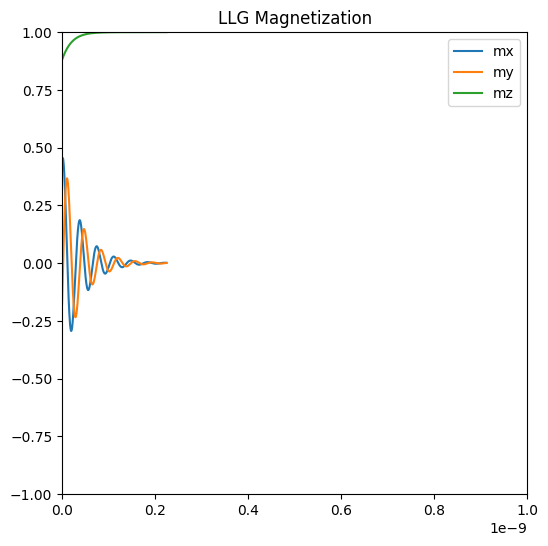

In [57]:
import LLGsim2
import importlib
importlib.reload(LLGsim2)

import numpy as np
import matplotlib.pyplot as plt

LLG = LLGsim2.LLGsim(Hext=np.array([0, 0, 1]), m0=np.array([0.5, -0.2, 1]), alpha=0.15, gamma=1.76e11, dt=5e-13, n_steps=450)

LLG.sim_m_vector()
print(LLG.m_steps)
LLG.animate_m_vector()
print('animating')
LLG.plot_m_components()


[[ 0.44022545 -0.17609018  0.88045091]
 [ 0.45399794 -0.13671896  0.88045091]
 [ 0.46425693 -0.09628967  0.88045091]
 [ 0.47092304 -0.0551152   0.88045091]
 [ 0.47394468 -0.01351419  0.88045091]
 [ 0.47329847  0.02819141  0.88045091]
 [ 0.4689894   0.06967883  0.88045091]
 [ 0.46105082  0.11062701  0.88045091]
 [ 0.44954417  0.15071904  0.88045091]
 [ 0.4345585   0.18964466  0.88045091]
 [ 0.41620979  0.22710262  0.88045091]
 [ 0.39464003  0.26280304  0.88045091]
 [ 0.37001615  0.29646962  0.88045091]
 [ 0.34252872  0.32784183  0.88045091]
 [ 0.31239046  0.35667687  0.88045092]
 [ 0.27983461  0.38275159  0.88045092]
 [ 0.24511312  0.40586419  0.88045092]
 [ 0.20849471  0.42583581  0.88045092]
 [ 0.17026275  0.4425119   0.88045092]
 [ 0.13071313  0.45576338  0.88045092]
 [ 0.09015192  0.46548771  0.88045092]
 [ 0.04889303  0.47160964  0.88045092]
 [ 0.00725576  0.47408178  0.88045092]
 [-0.03443767  0.472885    0.88045092]
 [-0.07586458  0.46802857  0.88045092]
 [-0.11670438  0.45955006

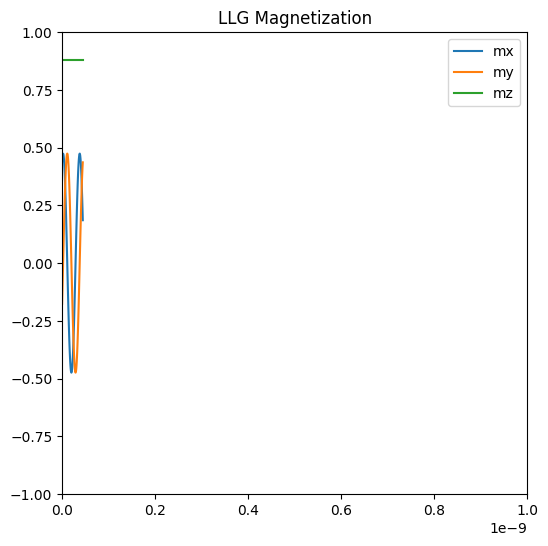

In [56]:
import LLGsim2
import importlib
importlib.reload(LLGsim2)

import numpy as np
import matplotlib.pyplot as plt

LLG = LLGsim2.LLGsim(Hext=np.array([0, 0, 1]), m0=np.array([0.5, -0.2, 1]), alpha=0, gamma=1.76e11, dt=5e-13, n_steps=90)

LLG.sim_m_vector()
print(LLG.m_steps)
LLG.animate_m_vector()
print('animating')
LLG.plot_m_components()


In [44]:
import numpy as np
import matplotlib.pyplot as plt

# ---- physics parameters ----
gamma = 1.76e11       # rad/(s·T)
alpha = 0.02          # Gilbert damping
dt = 1e-12            # time step [s]
n_steps = 200000      # total steps -> total_time = dt*n_steps
t = np.arange(n_steps) * dt

# DC field (Tesla) and RF drive
H_dc = np.array([0.0, 0.0, 0.1])     # 0.1 T along z -> f_res ~ (gamma/2pi)*0.1 = 2.8 GHz
H_rf_amp = 5e-4                       # Tesla amplitude of rf field (try 1e-5 - 1e-2)
f_drive = 2.8e9                       # drive frequency (Hz) - set near expected resonance

# SOT (damping-like) parameters (time-dependent amplitude)
# tau has units [1/s]; choose a value that produces visible precession.
tau_dl_amp = 5e8                      # amplitude of damping-like torque (1/s)
sigma = np.array([1.0, 0.0, 0.0])     # spin-polarization direction (unit vector)

# initial magnetization, slightly perturbed so not exactly aligned
m = np.array([1e-4, 0.0, 1.0])  # nearly +z but small x perturbation
m = m / np.linalg.norm(m)

# helper: llg precession+damping from H_eff (H in Tesla)
def llg_precess_damp(m, H):
    pref = gamma / (1 + alpha**2)
    mxh = np.cross(m, H)
    m_cross_mxh = np.cross(m, mxh)
    return -pref * mxh - pref * alpha * m_cross_mxh

# helper: SOT damping-like term (units 1/s multiply)
def sot_dl(m, tau_dl, sigma):
    # tau_dl * m x (m x sigma)
    return tau_dl * np.cross(m, np.cross(m, sigma))

# Integration: simple RK4 step integrating dm/dt = precess+damp + sot
def rk4_step(m, time_index):
    tt = time_index * dt
    # time-dependent H_rf and tau
    H_rf = H_rf_amp * np.cos(2 * np.pi * f_drive * tt) * np.array([1.0, 0.0, 0.0]) # RF along x
    H_eff = H_dc + H_rf

    tau_dl = tau_dl_amp * np.cos(2 * np.pi * f_drive * tt)  # oscillating SOT (in phase with current)
    def dm_dt_local(m_local, t_local):
        # For RK4 we don't need t_local separately because H_eff and tau depend on absolute time,
        # but we approximate them using the same time as passed in outer function (good for small dt).
        dmdt = llg_precess_damp(m_local, H_eff)
        dmdt = dmdt + sot_dl(m_local, tau_dl, sigma)
        return dmdt

    k1 = dm_dt_local(m, tt)
    k2 = dm_dt_local(m + 0.5 * dt * k1, tt + 0.5*dt)
    k3 = dm_dt_local(m + 0.5 * dt * k2, tt + 0.5*dt)
    k4 = dm_dt_local(m + dt * k3, tt + dt)
    m_new = m + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return m_new / np.linalg.norm(m_new)

# simulate and store
m_hist = np.zeros((n_steps, 3))
m_hist[0] = m.copy()
for i in range(1, n_steps):
    m = rk4_step(m, i-1)
    m_hist[i] = m

# downsample for plotting (e.g. plot every 100 steps to keep arrays small)
ds = 100
t_ds = t[::ds] * 1e9  # ns
m_ds = m_hist[::ds]

# plots
plt.figure(figsize=(10,5))
plt.plot(t_ds, m_ds[:,0], label='m_x')
plt.plot(t_ds, m_ds[:,1], label='m_y')
plt.plot(t_ds, m_ds[:,2], label='m_z')
plt.xlabel('Time (ns)')
plt.ylabel('m components')
plt.legend()
plt.title('Driven magnetization (H_rf + SOT DL). f_drive=%.2f GHz' % (f_drive*1e-9))
plt.tight_layout()
plt.show()

# FFT of m_x to see frequency content (short window near steady state)
import scipy.signal as sps
window_start = int(0.5 * n_steps)   # analyze second half
mx_window = m_hist[window_start:, 0]
# remove mean and taper
mx_window = mx_window - np.mean(mx_window)
freqs = np.fft.rfftfreq(len(mx_window), dt)
spec = np.abs(np.fft.rfft(mx_window))
# find peak near drive
peak_idx = np.argmax(spec)
print("Peak frequency (Hz):", freqs[peak_idx], " -> GHz:", freqs[peak_idx]*1e-9)

plt.figure(figsize=(6,3))
plt.semilogy(freqs*1e-9, spec)
plt.xlim(0, 10) # up to 10 GHz
plt.xlabel('Frequency (GHz)')
plt.ylabel('Amplitude (arb)')
plt.title('FFT of m_x')
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

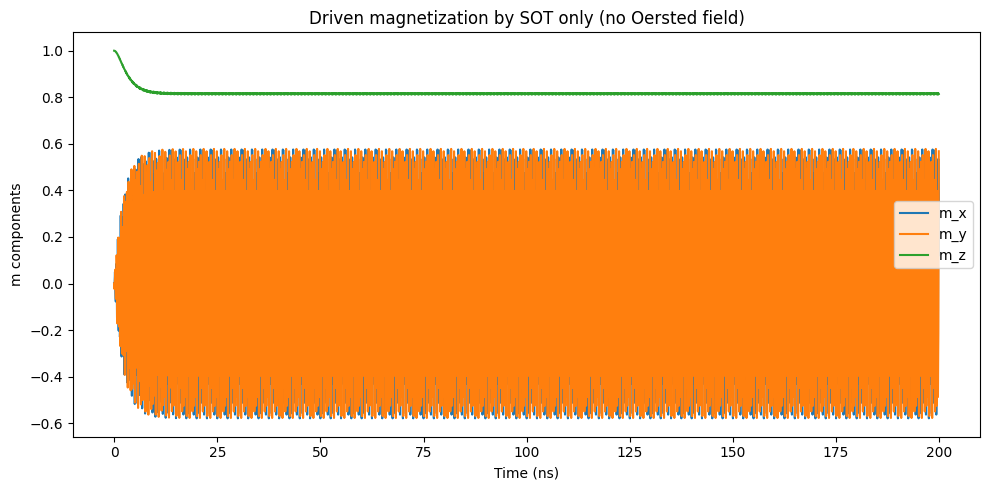

Peak frequency ≈ 2.800 GHz


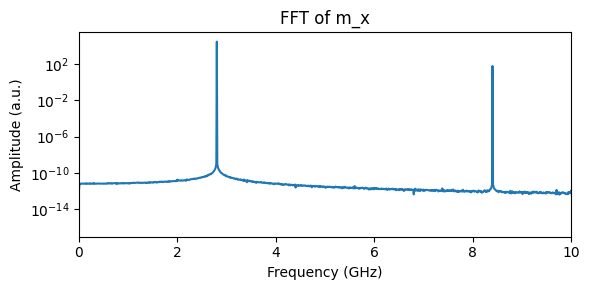

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sps

# ----- Physical parameters -----
gamma = 1.76e11      # rad / (s·T)
alpha = 0.02         # Gilbert damping
dt = 1e-12           # time step [s]
n_steps = 200000     # total steps
t = np.arange(n_steps) * dt

# Static field (Tesla)
H_dc = np.array([0.0, 0.0, 0.1])   # 0.1 T -> f_res ≈ 2.8 GHz
m = np.array([1e-4, 0.0, 1.0])
sigma = np.array([1.0, 0.0, 0.0]) # spin polarization direction (from spin Hall effect, along +x)

# Spin-orbit torque parameters
f_drive = 2.8e9                   # drive frequency (Hz) ≈ FMR
tau_dl_amp = 5e8                  # damping-like torque amplitude [1/s]
tau_fl_amp = 0e8                  # field-like torque amplitude [1/s] (set to 0 if not used)

# Initial magnetization (slightly tilted)
m /= np.linalg.norm(m)

# --- Helper functions ---

def llg_precess_damp(m, H):
    """Standard LLG precession + damping for given H (Tesla)."""
    pref = gamma / (1 + alpha**2)
    mxh = np.cross(m, H)
    m_cross_mxh = np.cross(m, mxh)
    return -pref * mxh - pref * alpha * m_cross_mxh

def sot_terms(m, tau_dl, tau_fl, sigma):
    """Damping-like and field-like SOT terms (1/s)."""
    dl = tau_dl * np.cross(m, np.cross(m, sigma))
    fl = tau_fl * np.cross(m, sigma)
    return dl + fl

def rk4_step(m, i):
    """One RK4 integration step."""
    tt = i * dt
    tau_dl = tau_dl_amp * np.cos(2 * np.pi * f_drive * tt)
    tau_fl = tau_fl_amp * np.cos(2 * np.pi * f_drive * tt)
    H_eff = H_dc

    def dm_dt_local(m_local):
        return llg_precess_damp(m_local, H_eff) + sot_terms(m_local, tau_dl, tau_fl, sigma)

    k1 = dm_dt_local(m)
    k2 = dm_dt_local(m + 0.5 * dt * k1)
    k3 = dm_dt_local(m + 0.5 * dt * k2)
    k4 = dm_dt_local(m + dt * k3)
    m_new = m + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return m_new / np.linalg.norm(m_new)

# --- Time integration ---
m_hist = np.zeros((n_steps, 3))
m_hist[0] = m
for i in range(1, n_steps):
    m = rk4_step(m, i - 1)
    m_hist[i] = m

# --- Plot magnetization components ---
ds = 100
t_ds = t[::ds] * 1e9
m_ds = m_hist[::ds]

plt.figure(figsize=(10,5))
plt.plot(t_ds, m_ds[:,0], label='m_x')
plt.plot(t_ds, m_ds[:,1], label='m_y')
plt.plot(t_ds, m_ds[:,2], label='m_z')
plt.xlabel('Time (ns)')
plt.ylabel('m components')
plt.legend()
plt.title('Driven magnetization by SOT only (no Oersted field)')
plt.tight_layout()
plt.show()

# --- FFT to see resonance frequency ---
window_start = int(0.5 * n_steps)
mx_window = m_hist[window_start:, 0] - np.mean(m_hist[window_start:, 0])
freqs = np.fft.rfftfreq(len(mx_window), dt)
spec = np.abs(np.fft.rfft(mx_window))
peak_idx = np.argmax(spec)
print(f"Peak frequency ≈ {freqs[peak_idx]*1e-9:.3f} GHz")

plt.figure(figsize=(6,3))
plt.semilogy(freqs*1e-9, spec)
plt.xlim(0, 10)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Amplitude (a.u.)')
plt.title('FFT of m_x')
plt.tight_layout()
plt.show()


2025-10-26 12:21:35.806 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-26 12:21:35.808 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-26 12:21:35.809 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-26 12:21:35.810 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-26 12:21:35.811 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-26 12:21:35.812 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-26 12:21:35.813 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-26 12:21:35.814 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

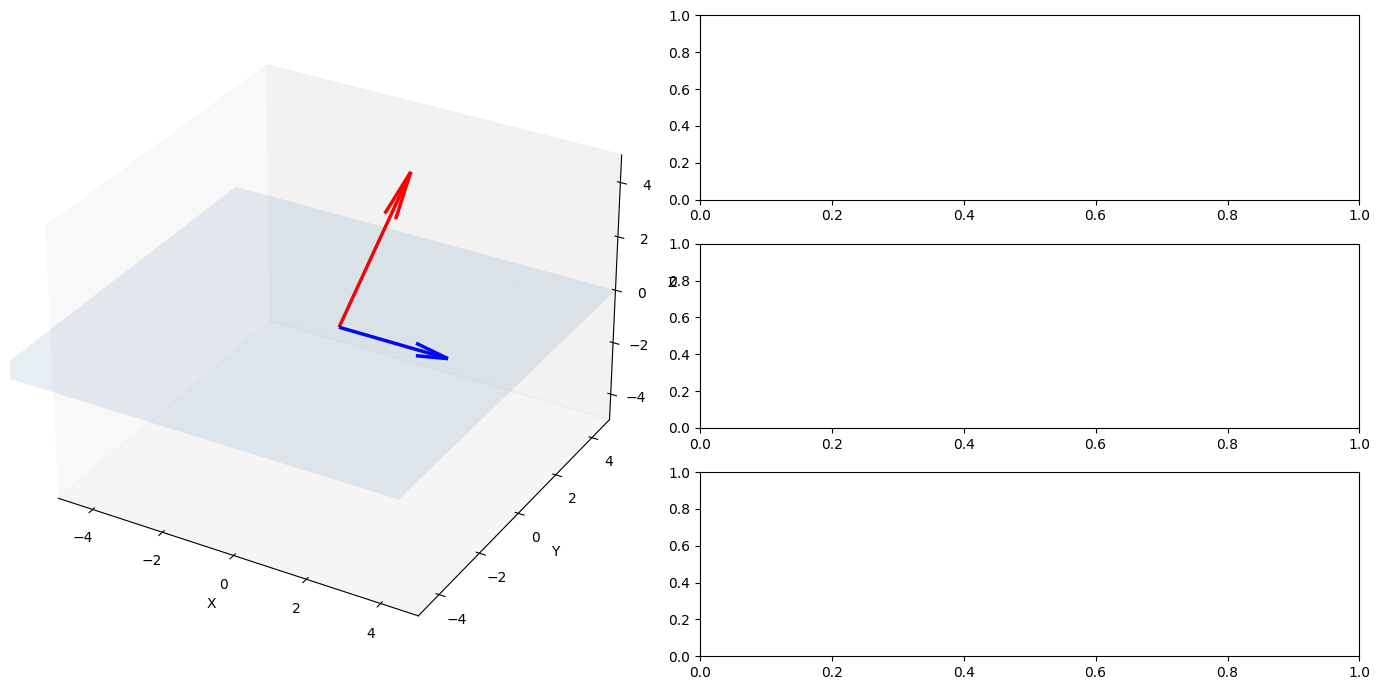

2025-10-26 12:21:36.937 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-26 12:21:37.880 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-26 12:21:37.882 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-26 12:21:37.883 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


[np.float64(3.0)]


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Wed Jan 20 17:30:54 2021

@author: richard
Solve the differential equation for magnetisation precession.

Given by: dm/dt = -g*(np.cross(m, B))-(g*alpha/Ms)*(np.cross(m0, np.cross(m0, B)))
"""

# import streamlit as st
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import
import matplotlib.pyplot as plt
import streamlit as st


plt.close('all')

g = 2 # gyromagnetic ratio
alpha = 0.16 # damping constant
t0 = 0
t=[t0]

fig = plt.figure(figsize=(14,7), tight_layout=True)
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_axis_off()


ax2 = fig.add_subplot(322)
ax3 = fig.add_subplot(324)
ax4 = fig.add_subplot(326)

xx, yy = np.meshgrid(range(-6, 6), range(-6, 6))


with st.sidebar:
    start = st.button('Start simulation')
    tab1, tab2 = st.tabs(["External field", "Magnetisation"])
    with tab1:
        st.markdown('#### Magnetic field direction:')
        Bx = st.slider('Bx', min_value=0.0,max_value=1.0, value=0.0, format='')
        By = st.slider('By', min_value=0.0,max_value=1.0, value=1.0, format='')
        Bz = st.slider('Bz', min_value=0.0,max_value=1.0, value=1.0, format='')
        st.markdown('#### Magnetic field amplitude:')
        Bs = st.slider('', min_value=1.0,max_value=5.0, value=5.0, step=0.5)
      

        
    with tab2:
        st.markdown('#### Magnetisation direction',)
        mx0 = st.slider('Mx', min_value=0.0,max_value=1.0, value=1.0, format='')
        my0 = st.slider('My', min_value=0.0,max_value=1.0, value=0.0, format='')
        mz0 = st.slider('Mz', min_value=0.0,max_value=1.0, value=0.0, format='')      
 #   with col3:
        st.markdown('#### Magnetisation amplitude:')
        Ms = st.slider('', min_value=1.0,max_value=5.0, value=3.0, step=0.5)
        st.markdown('#### Magnetic damping:')
        alpha = st.slider('', min_value=0.02,max_value=0.2, value=0.08)


B = np.array([Bx, By, Bz])
B = Bs*(B/np.linalg.norm(B))

m0 = np.array([mx0, my0, mz0])
m0 = Ms*(m0/np.linalg.norm(m0))

empty = st.empty()
with empty:
    ax1.cla()
    ax1.plot_surface(xx, yy, xx*0, alpha=0.1)
    ax1.set_xlim([-5, 5])
    ax1.set_ylim([-5, 5])
    ax1.set_zlim([-5, 5])
    ax1.quiver(0, 0, 0, B[0], B[1], B[2], length=1, color ='r', linewidth=2.5, label='B')
    ax1.quiver(0, 0, 0, m0[0], m0[1], m0[2], length=1, color='b', linewidth=2.5, label='M')
    # Hide grid lines
    ax1.grid(False)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')

    plt.pause(1e-6)
    ax1.legend()
    st.write(fig)


delta_t = 1e-3 #simulation step size (not real time)
n = 6000 # total simulation steps

mx = [m0[0]]
my = [m0[1]]
mz = [m0[2]]

if start:
    plt.close('all')
    with empty:
        for j in range(n+1):
            # Euler step method:
            dm_p = -g*(np.cross(m0, B)) # the change in m due to precession
            dm_d = -(g*alpha/Ms)*(np.cross(m0, np.cross(m0, B)))# the change in m due to damping
            dm = dm_p + dm_d # the total change in m
            m1 = (m0 + (delta_t*dm))
            # m1 = m1/np.linalg.norm(m1)
            t1 = t0 + delta_t
            
            mx.append(m1[0])
            my.append(m1[1])
            mz.append(m1[2])
            t.append(t1)
            #print('Time = {0}, Moment = {1}'.format(t1, m1))
            t0 = t1
            m0 = m1
            if j%250 == 0:
                #print(np.linalg.norm(m1))
                ax1.cla()
                ax1.plot_surface(xx, yy, xx*0, alpha=0.1)
                ax1.set_title(
                    'B = {0}, Ms = {1}, Damping = {2}, \n Simulation step = {3}'.format(
                        B, Ms, alpha, j))
                ax1.plot(mx, my, mz)
                ax1.quiver(0, 0, 0, B[0], B[1], B[2], length=1, color ='r', linewidth=2.5,
                           label='B')
                ax1.quiver(0, 0, 0, m1[0], m1[1], m1[2], length=1, color='b', linewidth=2.5,
                           label='M')
                # Hide grid lines
                ax1.grid(False)
                ax1.legend()

                # Hide axes ticks
                ax1.set_xticks([])
                ax1.set_yticks([])
                ax1.set_zticks([])
                
                ax2.cla()
                ax2.plot(t,mx)
                ax3.cla()
                ax3.plot(t,my)
                ax4.cla()
                ax4.plot(t,mz)
                
                ax2.set_ylabel('Mx')
                ax3.set_ylabel('My')
                ax4.set_ylabel('Mz')
                ax4.set_xlabel('time step')
                
                ax1.set_xlim([-Bs, Bs])
                ax1.set_ylim([-Bs, Bs])
                ax1.set_zlim([-Bs, Bs])
                
                plt.pause(1e-6)
                st.write(fig)
print(mx) 
            